# 1) Import Libraries

In [267]:
import os
import numpy as np
import torchvision.transforms as transforms
from torchvision.models import inception_v3,Inception_V3_Weights
import torch.functional as F
from torch import max,no_grad,manual_seed
from torchvision.utils import make_grid
import torch.optim.adamw as A
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
import torch.nn as nn
from torch.utils.data import Subset
import matplotlib.pyplot as plt
%matplotlib inline

# 2) Define All Needed Constant Variables

In [215]:
PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Cancer Images Dataset\Dataset_BUSI_with_GT"

IMG_SIZE = (299,299)

SPLIT_SIZES = [0.8,0.2]

PRETRAINED = True
NUM_OF_CLASSES = 3

TRANSFORMS = [transforms.Resize(IMG_SIZE),transforms.ColorJitter(brightness=[0.2,1.8]),transforms.GaussianBlur(kernel_size=(3,3)),transforms.RandomCrop((280,280)),transforms.ToTensor()]

PREMUTE_SIZE = (1,2,0)

BATCH_SIZE = 20
EPOCHS = 10

os.listdir(PATH)

['benign', 'malignant', 'normal']

### - Show Some random Images

Text(0.5, 1.0, 'Dataset Name: malignant Label: 1')

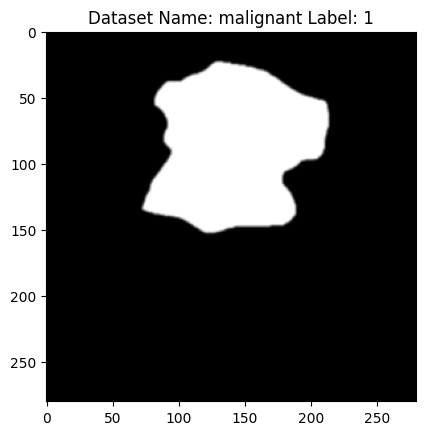

In [ ]:
dataset = ImageFolder(PATH,transforms.Compose(TRANSFORMS))

idx = np.random.randint(len(dataset))

img, label = dataset[idx]


plt.imshow(img.permute(PREMUTE_SIZE))
plt.title(f"Dataset Name: {dataset.classes[label]} Label: {label}")

# 3) Filter Dataset (Filter All Not Masks Images)

In [ ]:
valid_indices = [i for i, (path, _) in enumerate(dataset.samples) if "mask" not in path]

filtered_dataset = Subset(dataset, valid_indices)
len(filtered_dataset)

Text(0.5, 1.0, 'Dataset Name: benign Label: 0')

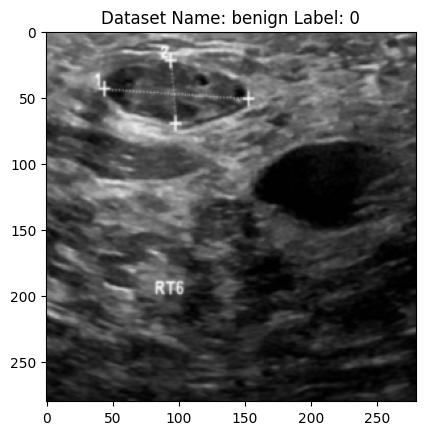

In [ ]:
idx = np.random.randint(len(filtered_dataset))

img, label = filtered_dataset[idx]

plt.imshow(img.permute(PREMUTE_SIZE))
plt.title(f"Dataset Name: {dataset.classes[label]} Label: {label}")